In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

BASE      = '/content/drive/MyDrive/customer-segmentation'
PROCESSED = f'{BASE}/data/processed'

print("Ready!")

Ready!


In [3]:
df = pd.read_csv(f'{PROCESSED}/online_retail_clean.csv',
                 parse_dates=['InvoiceDate'])

print(f"Shape: {df.shape}")
print(f"Date range: {df['InvoiceDate'].min()} to {df['InvoiceDate'].max()}")
print(f"Unique customers: {df['Customer ID'].nunique():,}")

Shape: (392693, 8)
Date range: 2010-12-01 08:26:00 to 2011-12-09 12:50:00
Unique customers: 4,338


In [4]:
# We use the day after the last transaction as our reference point
# This is standard practice in RFM analysis

reference_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)
print(f"Reference date: {reference_date}")

Reference date: 2011-12-10 12:50:00


In [5]:
# Each row needs a total value = Quantity × Price
df['Revenue'] = df['Quantity'] * df['Price']

print("Revenue column created!")
print(df[['Quantity', 'Price', 'Revenue']].head())

Revenue column created!
   Quantity  Price  Revenue
0         6   2.55    15.30
1         6   3.39    20.34
2         8   2.75    22.00
3         6   3.39    20.34
4         6   3.39    20.34


In [6]:
rfm = df.groupby('Customer ID').agg(
    Recency   = ('InvoiceDate', lambda x: (reference_date - x.max()).days),
    Frequency = ('Invoice', 'nunique'),
    Monetary  = ('Revenue', 'sum')
).reset_index()

print(f"RFM table shape: {rfm.shape}")
print(f"\nSample RFM values:")
print(rfm.head(10))

RFM table shape: (4338, 4)

Sample RFM values:
   Customer ID  Recency  Frequency  Monetary
0        12346      326          1  77183.60
1        12347        2          7   4310.00
2        12348       75          4   1797.24
3        12349       19          1   1757.55
4        12350      310          1    334.40
5        12352       36          8   2506.04
6        12353      204          1     89.00
7        12354      232          1   1079.40
8        12355      214          1    459.40
9        12356       23          3   2811.43


In [7]:
print("=== RFM STATISTICS ===")
print(rfm[['Recency', 'Frequency', 'Monetary']].describe())

=== RFM STATISTICS ===
           Recency    Frequency       Monetary
count  4338.000000  4338.000000    4338.000000
mean     92.536422     4.272015    2048.692230
std     100.014169     7.697998    8985.229676
min       1.000000     1.000000       3.750000
25%      18.000000     1.000000     306.482500
50%      51.000000     2.000000     668.570000
75%     142.000000     5.000000    1660.597500
max     374.000000   209.000000  280206.020000


In [8]:
print(f"Negative Monetary values: {(rfm['Monetary'] < 0).sum()}")
print(f"Zero Frequency: {(rfm['Frequency'] == 0).sum()}")
print(f"Zero Recency: {(rfm['Recency'] == 0).sum()}")
print(f"\nTop 5 spenders:")
print(rfm.nlargest(5, 'Monetary')[['Customer ID', 'Recency', 'Frequency', 'Monetary']])
print(f"\nTop 5 most frequent buyers:")
print(rfm.nlargest(5, 'Frequency')[['Customer ID', 'Recency', 'Frequency', 'Monetary']])

Negative Monetary values: 0
Zero Frequency: 0
Zero Recency: 0

Top 5 spenders:
      Customer ID  Recency  Frequency   Monetary
1689        14646        2         73  280206.02
4201        18102        1         60  259657.30
3728        17450        8         46  194390.79
3008        16446        1          2  168472.50
1879        14911        1        201  143711.17

Top 5 most frequent buyers:
      Customer ID  Recency  Frequency   Monetary
326         12748        1        209   33053.19
1879        14911        1        201  143711.17
4010        17841        2        124   40519.84
562         13089        3         97   58762.08
1661        14606        1         93   12076.15


In [9]:
import os
os.makedirs(f'{BASE}/outputs/figures', exist_ok=True)
print("Folders created!")

Folders created!


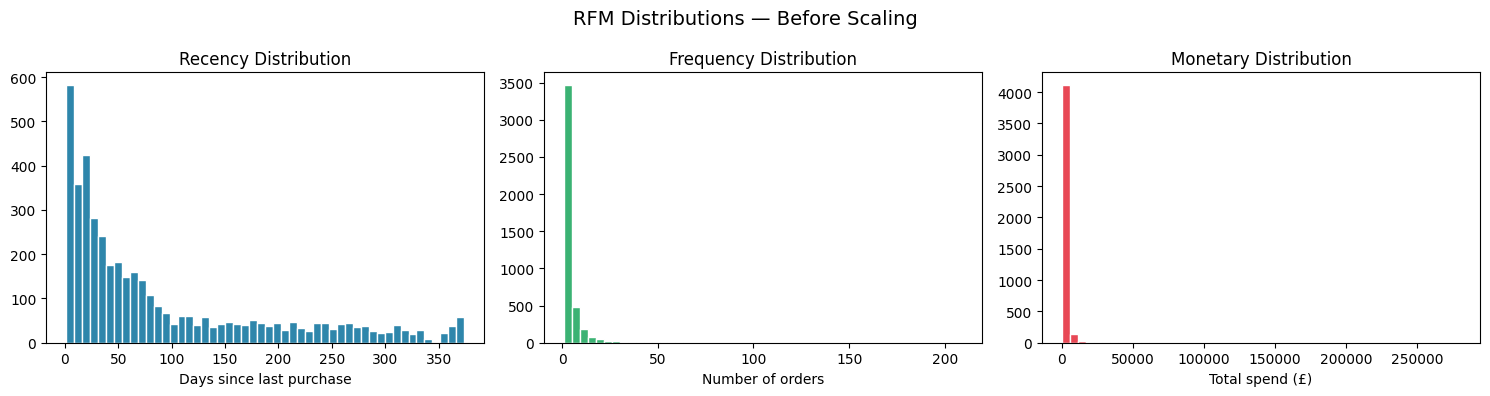

Plot saved!


In [10]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(rfm['Recency'], bins=50, color='#2E86AB', edgecolor='white')
axes[0].set_title('Recency Distribution')
axes[0].set_xlabel('Days since last purchase')

axes[1].hist(rfm['Frequency'], bins=50, color='#3BB273', edgecolor='white')
axes[1].set_title('Frequency Distribution')
axes[1].set_xlabel('Number of orders')

axes[2].hist(rfm['Monetary'], bins=50, color='#E84855', edgecolor='white')
axes[2].set_title('Monetary Distribution')
axes[2].set_xlabel('Total spend (£)')

plt.suptitle('RFM Distributions — Before Scaling', fontsize=14)
plt.tight_layout()
plt.savefig(f'{BASE}/outputs/figures/rfm_distributions.png', dpi=150)
plt.show()
print("Plot saved!")

In [11]:
rfm_log = rfm.copy()

rfm_log['Recency']   = np.log1p(rfm['Recency'])
rfm_log['Frequency'] = np.log1p(rfm['Frequency'])
rfm_log['Monetary']  = np.log1p(rfm['Monetary'])

print("Log transformation applied!")
print(rfm_log[['Recency', 'Frequency', 'Monetary']].describe())

Log transformation applied!
           Recency    Frequency     Monetary
count  4338.000000  4338.000000  4338.000000
mean      3.830734     1.345582     6.588567
std       1.340261     0.683104     1.258439
min       0.693147     0.693147     1.558145
25%       2.944439     0.693147     5.728418
50%       3.951244     1.098612     6.506636
75%       4.962845     1.791759     7.415535
max       5.926926     5.347108    12.543284


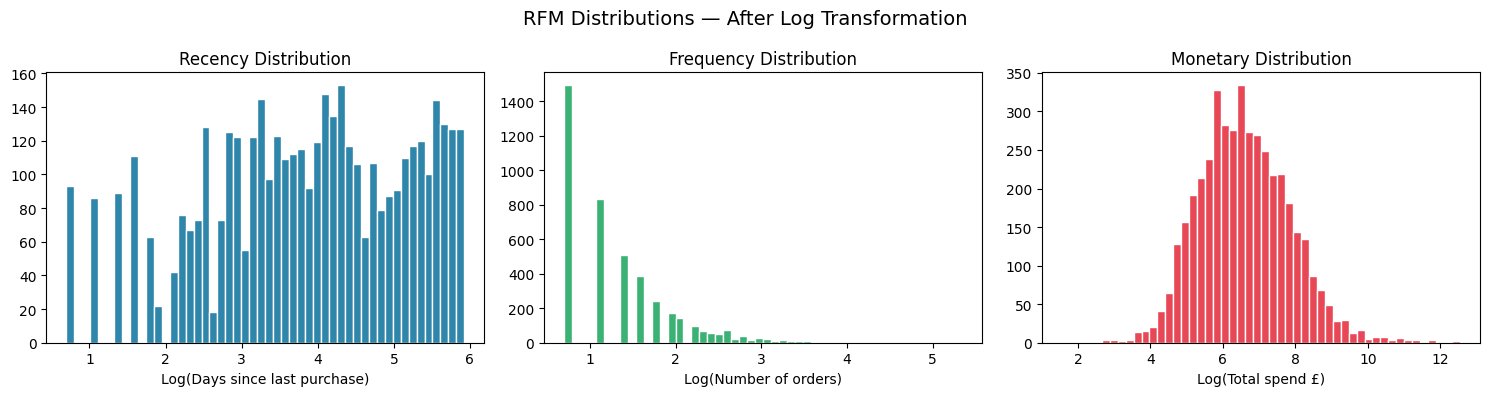

Plot saved!


In [12]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(rfm_log['Recency'], bins=50, color='#2E86AB', edgecolor='white')
axes[0].set_title('Recency Distribution')
axes[0].set_xlabel('Log(Days since last purchase)')

axes[1].hist(rfm_log['Frequency'], bins=50, color='#3BB273', edgecolor='white')
axes[1].set_title('Frequency Distribution')
axes[1].set_xlabel('Log(Number of orders)')

axes[2].hist(rfm_log['Monetary'], bins=50, color='#E84855', edgecolor='white')
axes[2].set_title('Monetary Distribution')
axes[2].set_xlabel('Log(Total spend £)')

plt.suptitle('RFM Distributions — After Log Transformation', fontsize=14)
plt.tight_layout()
plt.savefig(f'{BASE}/outputs/figures/rfm_distributions_log.png', dpi=150)
plt.show()
print("Plot saved!")

In [13]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

rfm_scaled = scaler.fit_transform(
    rfm_log[['Recency', 'Frequency', 'Monetary']]
)

# Convert back to dataframe
rfm_scaled = pd.DataFrame(
    rfm_scaled,
    columns=['Recency', 'Frequency', 'Monetary']
)

print("Scaling complete!")
print(f"\nShape: {rfm_scaled.shape}")
print(f"\nMean after scaling (should be ~0):")
print(rfm_scaled.mean().round(4))
print(f"\nStd after scaling (should be ~1):")
print(rfm_scaled.std().round(4))

Scaling complete!

Shape: (4338, 3)

Mean after scaling (should be ~0):
Recency     -0.0
Frequency   -0.0
Monetary     0.0
dtype: float64

Std after scaling (should be ~1):
Recency      1.0001
Frequency    1.0001
Monetary     1.0001
dtype: float64


In [14]:
# Save RFM table (original values — for business reporting)
rfm.to_csv(f'{PROCESSED}/rfm.csv', index=False)

# Save scaled features (for clustering model)
rfm_scaled.to_csv(f'{PROCESSED}/rfm_scaled.csv', index=False)

print("Files saved!")
print(f"rfm.csv → {rfm.shape}")
print(f"rfm_scaled.csv → {rfm_scaled.shape}")

Files saved!
rfm.csv → (4338, 4)
rfm_scaled.csv → (4338, 3)


In [ ]:
# ================================================
# FEATURE ENGINEERING SUMMARY
# ================================================
# Input:  392,693 transactions, 4,338 customers
# Output: 4,338 rows × 3 RFM features
#
# Steps applied:
# ✅ Revenue column created (Quantity × Price)
# ✅ RFM calculated per customer
#    - Recency:   days since last purchase
#    - Frequency: unique invoices count
#    - Monetary:  total revenue spent
# ✅ Log transformation applied (np.log1p)
#    - Reduces impact of outliers
# ✅ StandardScaler applied
#    - Mean = 0, Std = 1 for all features
#
# Ready for K-Means clustering!
# ================================================